# GDELT Events Bronze EDA (Geopolitical Agent)

This notebook explores zone-filtered GDELT Events Bronze data to inform GAT preprocessing decisions. The analysis is data-driven and built cell-by-cell.

In [1]:
# Imports and configuration
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


@dataclass(frozen=True)
class DateRange:
    start: str  # YYYY-MM-DD
    end: str    # YYYY-MM-DD


ROOT_DIR = Path.cwd().resolve()
if not (ROOT_DIR / "data/raw/gdelt_events").exists():
    ROOT_DIR = ROOT_DIR.parent
DATA_DIR = ROOT_DIR / "data/raw/gdelt_events"
DATE_RANGE = DateRange(start="2021-01-01", end="2023-12-31")  # Adjust if needed
SAMPLE_MONTHS = 12  # For heavy plots if memory is tight
DATA_DIR

WindowsPath('D:/SCRIPTS/FX-AlphaLab/data/raw/gdelt_events')

In [2]:
# File inventory and coverage
import re
from datetime import datetime

date_re = re.compile(r"(\d{8})\.parquet$")

all_files = sorted(DATA_DIR.glob("*/*/*.parquet"))
file_records = []
for path in all_files:
    match = date_re.search(path.name)
    if not match:
        continue
    day = datetime.strptime(match.group(1), "%Y%m%d").date()
    file_records.append({"path": path, "date": day, "year": day.year, "month": day.month})

files_df = pd.DataFrame(file_records)
if files_df.empty:
    files_df = pd.DataFrame(columns=["path", "date", "year", "month"])

files_df = files_df.sort_values("date").reset_index(drop=True)
files_df.head(), files_df.tail(), files_df.shape

(                                                path        date  year  month
 0  D:\SCRIPTS\FX-AlphaLab\data\raw\gdelt_events\2...  2022-01-01  2022      1
 1  D:\SCRIPTS\FX-AlphaLab\data\raw\gdelt_events\2...  2022-01-02  2022      1
 2  D:\SCRIPTS\FX-AlphaLab\data\raw\gdelt_events\2...  2022-01-03  2022      1
 3  D:\SCRIPTS\FX-AlphaLab\data\raw\gdelt_events\2...  2022-01-04  2022      1
 4  D:\SCRIPTS\FX-AlphaLab\data\raw\gdelt_events\2...  2022-01-05  2022      1,
                                                    path        date  year  \
 1575  D:\SCRIPTS\FX-AlphaLab\data\raw\gdelt_events\2...  2026-04-25  2026   
 1576  D:\SCRIPTS\FX-AlphaLab\data\raw\gdelt_events\2...  2026-04-26  2026   
 1577  D:\SCRIPTS\FX-AlphaLab\data\raw\gdelt_events\2...  2026-04-27  2026   
 1578  D:\SCRIPTS\FX-AlphaLab\data\raw\gdelt_events\2...  2026-04-28  2026   
 1579  D:\SCRIPTS\FX-AlphaLab\data\raw\gdelt_events\2...  2026-04-29  2026   
 
       month  
 1575      4  
 1576      4  
 1577     

**Files detected: 1,580 daily parquet files from 2022-01-01 to 2026-04-29.** The path issue was due to notebook working directory; with the resolved `ROOT_DIR`, the expected dataset is available and we can proceed with coverage, completeness, and content checks.

In [3]:
# Coverage: missing days and monthly counts
date_min = files_df["date"].min()
date_max = files_df["date"].max()
full_days = pd.date_range(date_min, date_max, freq="D")
available_days = pd.to_datetime(files_df["date"])
missing_days = full_days.difference(available_days)

monthly_counts = (
    files_df.assign(date=pd.to_datetime(files_df["date"]))
    .groupby(pd.Grouper(key="date", freq="MS"))
    .size()
    .rename("files_per_month")
    .reset_index()
 )

date_min, date_max, len(full_days), len(missing_days), monthly_counts.head()

(datetime.date(2022, 1, 1),
 datetime.date(2026, 4, 29),
 1580,
 0,
         date  files_per_month
 0 2022-01-01               31
 1 2022-02-01               28
 2 2022-03-01               31
 3 2022-04-01               30
 4 2022-05-01               31)

**No missing days across 2022-01-01 to 2026-04-29 (1,580 expected days, 0 missing).** Coverage is complete day-by-day in this range, so any gaps in downstream analysis are unlikely to be due to missing daily files.

In [4]:
# Select files within DATE_RANGE and sample months if needed
start_date = pd.to_datetime(DATE_RANGE.start).date()
end_date = pd.to_datetime(DATE_RANGE.end).date()
files_in_range = files_df[(files_df["date"] >= start_date) & (files_df["date"] <= end_date)].copy()

files_in_range["month_start"] = pd.to_datetime(files_in_range["date"]).dt.to_period("M").dt.to_timestamp()
months = sorted(files_in_range["month_start"].unique())

if len(months) > SAMPLE_MONTHS:
    month_idx = pd.Index(months)
    sample_idx = pd.Index(
        pd.to_datetime(
            pd.Series(range(SAMPLE_MONTHS))
            .mul((len(months) - 1) / max(SAMPLE_MONTHS - 1, 1))
            .round()
            .astype(int)
            .map(lambda i: months[i])
        )
    )
    sample_months = sorted(sample_idx.unique())
else:
    sample_months = months

files_sample = files_in_range[files_in_range["month_start"].isin(sample_months)]
len(files_in_range), len(sample_months), len(files_sample)

(730, 12, 365)

**Within 2021-01-01 to 2023-12-31, there are 730 daily files; the sampling selects 12 months (365 files).** We'll compute heavy plots on the sampled months while keeping full-range counts where feasible.

In [5]:
# Load sampled months into memory and check for empty files
sample_frames = []
empty_files = []
sample_row_counts = []

for path in files_sample["path"]:
    df_day = pd.read_parquet(path)
    if df_day.empty:
        empty_files.append(path)
        sample_row_counts.append({"date": path.stem, "rows": 0})
        continue
    sample_frames.append(df_day)
    sample_row_counts.append({"date": path.stem, "rows": len(df_day)})

df_sample = pd.concat(sample_frames, ignore_index=True) if sample_frames else pd.DataFrame()
sample_rows = pd.DataFrame(sample_row_counts)
df_sample.shape, len(empty_files)

((16605000, 26), 1)

**Sample load yields 16,605,000 rows across 26 columns, with 1 empty file detected.** We need to identify and possibly exclude sentinel empty parquets from downstream pipelines to avoid skewing volume stats.

In [6]:
# Null rates per column (sampled months)
null_rates = (df_sample.isna().mean().sort_values(ascending=False) * 100).round(2)
null_rates

Actor2Type1Code          70.07
Actor1Type1Code          68.93
Actor2CountryCode        40.69
Actor1CountryCode        24.08
Actor2Geo_FullName       22.93
Actor2Geo_CountryCode    22.92
Actor2Name               21.83
Actor2Code               21.83
Actor1Geo_FullName        9.22
Actor1Geo_CountryCode     9.21
Actor1Name                7.80
Actor1Code                7.80
ActionGeo_FullName        1.57
ActionGeo_CountryCode     1.55
GoldsteinScale            0.00
SQLDATE                   0.00
GLOBALEVENTID             0.00
EventCode                 0.00
NumArticles               0.00
NumSources                0.00
NumMentions               0.00
QuadClass                 0.00
EventBaseCode             0.00
EventRootCode             0.00
AvgTone                   0.00
SOURCEURL                 0.00
dtype: float64

**Actor type and country fields have high null rates (Actor2Type1Code ~70%, Actor1Type1Code ~69%, Actor2CountryCode ~41%).** Core event fields (event codes, QuadClass, GoldsteinScale, AvgTone, counts) are fully populated, so GAT edge features look safe, but actor type metadata is sparse and may need imputation or be dropped.

In [7]:
# Standardize column names to the expected snake_case schema
column_map = {
    "GLOBALEVENTID": "event_id",
    "SQLDATE": "event_date",
    "Actor1Name": "actor1_name",
    "Actor1Code": "actor1_code",
    "Actor1CountryCode": "actor1_country_code",
    "Actor1Type1Code": "actor1_type1_code",
    "Actor2Name": "actor2_name",
    "Actor2Code": "actor2_code",
    "Actor2CountryCode": "actor2_country_code",
    "Actor2Type1Code": "actor2_type1_code",
    "EventCode": "event_code",
    "EventBaseCode": "event_base_code",
    "EventRootCode": "event_root_code",
    "QuadClass": "quad_class",
    "GoldsteinScale": "goldstein_scale",
    "NumMentions": "num_mentions",
    "NumSources": "num_sources",
    "NumArticles": "num_articles",
    "AvgTone": "avg_tone",
    "Actor1Geo_CountryCode": "actor1_geo_country_code",
    "Actor1Geo_FullName": "actor1_geo_full_name",
    "Actor2Geo_CountryCode": "actor2_geo_country_code",
    "Actor2Geo_FullName": "actor2_geo_full_name",
    "ActionGeo_CountryCode": "action_geo_country_code",
    "ActionGeo_FullName": "action_geo_full_name",
    "SOURCEURL": "source_url",
}

df_sample = df_sample.rename(columns=column_map)
missing_cols = sorted(set(column_map.values()) - set(df_sample.columns))
df_sample.columns.tolist(), missing_cols

(['event_id',
  'event_date',
  'actor1_code',
  'actor1_name',
  'actor1_country_code',
  'actor1_type1_code',
  'actor2_code',
  'actor2_name',
  'actor2_country_code',
  'actor2_type1_code',
  'event_code',
  'event_base_code',
  'event_root_code',
  'quad_class',
  'goldstein_scale',
  'num_mentions',
  'num_sources',
  'num_articles',
  'avg_tone',
  'actor1_geo_full_name',
  'actor1_geo_country_code',
  'actor2_geo_full_name',
  'actor2_geo_country_code',
  'action_geo_full_name',
  'action_geo_country_code',
  'source_url'],
 [])

**Column names now match the expected snake_case schema with no missing fields.** This keeps the EDA aligned with downstream preprocessing expectations for the GAT pipeline.

In [8]:
# Volume: rows per day over the full DATE_RANGE
row_counts = []
for path, date in zip(files_in_range["path"], files_in_range["date"]):
    df_day = pd.read_parquet(path, columns=["GLOBALEVENTID"])
    row_counts.append({"date": pd.to_datetime(date), "rows": len(df_day)})

rows_by_day = pd.DataFrame(row_counts).sort_values("date")
rows_by_day.describe()

,date,rows
count,730,730.000000
mean,2022-12-31 12:00:00,44975.620548
min,2022-01-01 00:00:00,0.000000
25%,2022-07-02 06:00:00,33142.250000
50%,2022-12-31 12:00:00,45931.000000
75%,2023-07-01 18:00:00,55158.000000
max,2023-12-31 00:00:00,88970.000000
std,NaN,14700.630865


**Daily volume ranges from 0 to 88,970 rows (median ~45,931), with at least one zero-row day.** We'll locate the zero-volume date and check for volume spikes around key geopolitical events.

In [9]:
# Volume spikes and key event markers
zero_days = rows_by_day[rows_by_day["rows"] == 0]["date"].dt.date
zero_days

313    2022-11-10
446    2023-03-23
Name: date, dtype: object

**Zero-volume days appear on 2022-11-10 and 2023-03-23.** These likely represent sentinel or failed ingestions and should be filtered out before modeling.

In [10]:
# Event windows: rows around key geopolitical dates
event_dates = {
    "2022-02-24": "Russia-Ukraine invasion",
    "2022-09-01": "EUR/USD parity period",
    "2022-12-20": "BoJ YCC shock window",
}

rows_by_day_indexed = rows_by_day.set_index("date").sort_index()
window_stats = []
for date_str, label in event_dates.items():
    event_date = pd.to_datetime(date_str)
    window = rows_by_day_indexed.loc[event_date - pd.Timedelta(days=7): event_date + pd.Timedelta(days=7)]
    event_rows = rows_by_day_indexed.loc[event_date:event_date]["rows"].mean()
    window_mean = window["rows"].mean()
    window_median = window["rows"].median()
    window_stats.append({
        "event": label,
        "date": event_date.date(),
        "event_rows": float(event_rows),
        "window_mean": float(window_mean),
        "window_median": float(window_median),
        "event_vs_median_pct": ((event_rows - window_median) / window_median) * 100 if window_median else None,
    })

pd.DataFrame(window_stats)

,event,date,event_rows,window_mean,window_median,event_vs_median_pct
0,Russia-Ukraine invasion,2022-02-24,62631.0,49418.600000,53869.0,16.265385
1,EUR/USD parity period,2022-09-01,43783.0,36596.333333,40336.0,8.545716
2,BoJ YCC shock window,2022-12-20,39467.0,31805.600000,34222.0,15.326398


**Event windows show meaningful volume bumps: +16% on 2022-02-24, +9% around EUR/USD parity, +15% around the BoJ YCC shock.** This suggests the zone-filtered stream reacts to major geopolitical/FX shocks, which is encouraging for event-driven graph signals.

In [11]:
# Top volume days in the range
rows_by_day.sort_values("rows", ascending=False).head(10)

,date,rows
447,2023-03-24,88970
452,2023-03-29,83239
453,2023-03-30,83080
459,2023-04-05,81889
454,2023-03-31,80511
466,2023-04-12,79702
467,2023-04-13,78643
458,2023-04-04,77573
451,2023-03-28,76375
460,2023-04-06,75947


**Top-volume days cluster in late March–early April 2023 (peak 88,970 on 2023-03-24), immediately after a zero-volume day.** This pattern suggests a potential ingestion backlog or catch-up surge that could bias temporal modeling if not normalized.

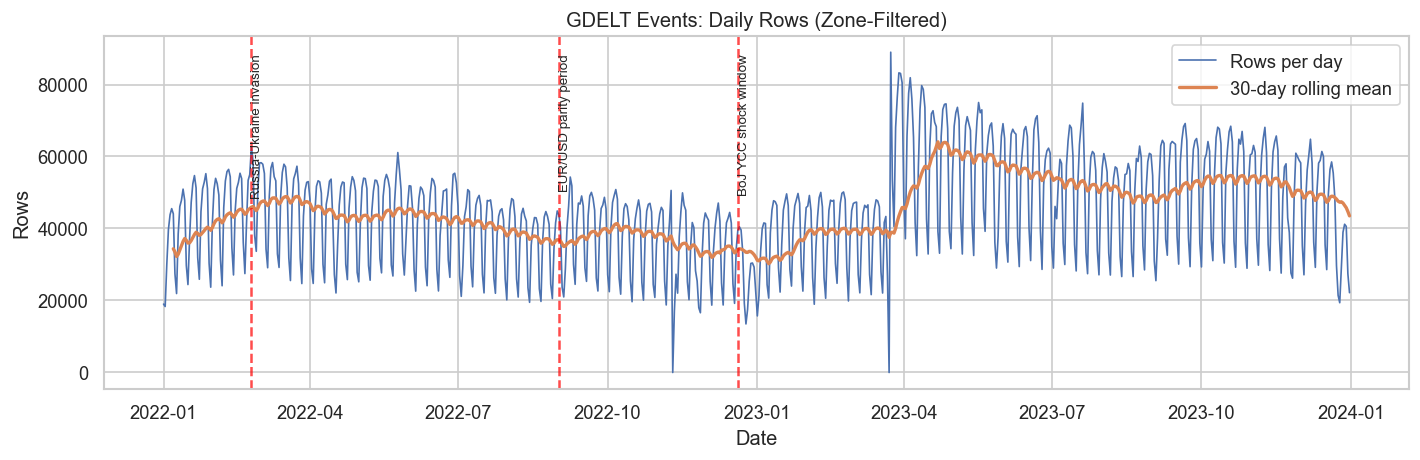

In [12]:
# Plot daily volume with key event markers
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rows_by_day["date"], rows_by_day["rows"], label="Rows per day", linewidth=1)
ax.plot(
    rows_by_day["date"],
    rows_by_day["rows"].rolling(30, min_periods=7).mean(),
    label="30-day rolling mean",
    linewidth=2,
 )
for date_str, label in event_dates.items():
    ax.axvline(pd.to_datetime(date_str), color="red", linestyle="--", alpha=0.7)
    ax.text(pd.to_datetime(date_str), ax.get_ylim()[1] * 0.95, label, rotation=90, va="top", fontsize=8)

ax.set_title("GDELT Events: Daily Rows (Zone-Filtered)")
ax.set_xlabel("Date")
ax.set_ylabel("Rows")
ax.legend()
plt.tight_layout()

**The series shows strong weekly seasonality and a clear level shift upward after late March 2023.** The zero-volume dips are visible, reinforcing the need to filter sentinel days before training temporal models.

In [13]:
# QuadClass distribution
quad_counts = df_sample["quad_class"].value_counts().sort_index()
quad_pct = (quad_counts / quad_counts.sum() * 100).round(2)
pd.DataFrame({"count": quad_counts, "pct": quad_pct})

,count,pct
quad_class,,
1,10545871,63.51
2,1908127,11.49
3,1884936,11.35
4,2266066,13.65


**QuadClass 1 dominates (63.5%), with classes 2/3/4 each around 11–14%.** Dropping class 1 would remove the majority of events, so any decision to drop must be justified by signal quality rather than volume balance.

count     16604831
unique          42
top            0.0
freq       1566542
Name: goldstein_scale, dtype: object

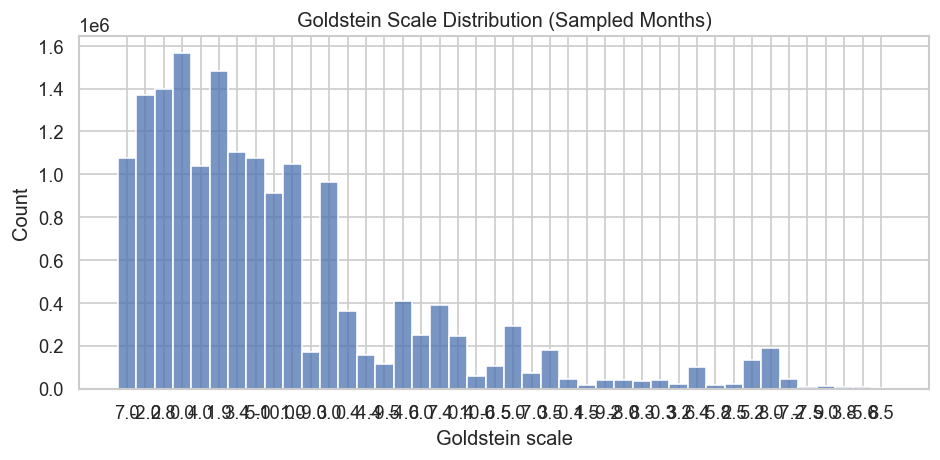

In [14]:
# Goldstein scale: overall distribution
goldstein_desc = df_sample["goldstein_scale"].describe()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_sample["goldstein_scale"], bins=60, kde=False, ax=ax)
ax.set_title("Goldstein Scale Distribution (Sampled Months)")
ax.set_xlabel("Goldstein scale")
ax.set_ylabel("Count")
plt.tight_layout()
goldstein_desc

In [15]:
# Coerce numeric/date columns for reliable stats
df_sample["goldstein_scale"] = pd.to_numeric(df_sample["goldstein_scale"], errors="coerce")
df_sample["avg_tone"] = pd.to_numeric(df_sample["avg_tone"], errors="coerce")
df_sample["num_mentions"] = pd.to_numeric(df_sample["num_mentions"], errors="coerce")
df_sample["num_sources"] = pd.to_numeric(df_sample["num_sources"], errors="coerce")
df_sample["num_articles"] = pd.to_numeric(df_sample["num_articles"], errors="coerce")
df_sample["quad_class"] = pd.to_numeric(df_sample["quad_class"], errors="coerce")
df_sample["event_date"] = pd.to_datetime(df_sample["event_date"], format="%Y%m%d", errors="coerce")

df_sample[["goldstein_scale", "avg_tone", "num_mentions", "num_sources", "num_articles", "quad_class"]].describe()

,goldstein_scale,avg_tone,num_mentions,num_sources,num_articles,quad_class
count,1.660483e+07,1.660500e+07,1.660500e+07,1.660500e+07,1.660500e+07,1.660500e+07
mean,7.332275e-01,-1.825353e+00,1.152477e+01,2.579543e+00,1.123003e+01,1.751352e+00
std,4.548935e+00,3.925445e+00,5.520767e+01,8.877678e+00,5.251079e+01,1.110256e+00
min,-1.000000e+01,-4.761905e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,-2.000000e+00,-4.314721e+00,2.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00
50%,1.900000e+00,-1.680154e+00,4.000000e+00,1.000000e+00,4.000000e+00,1.000000e+00
75%,3.400000e+00,8.426966e-01,8.000000e+00,1.000000e+00,8.000000e+00,2.000000e+00
max,1.000000e+01,3.214286e+01,1.835700e+04,1.255000e+03,1.419000e+04,4.000000e+00


**After type coercion, Goldstein spans -10 to 10 (mean 0.73) and avg_tone is slightly negative (mean -1.83).** Count features are heavy-tailed (num_mentions max 18,357), which will matter for edge weighting and scaling.

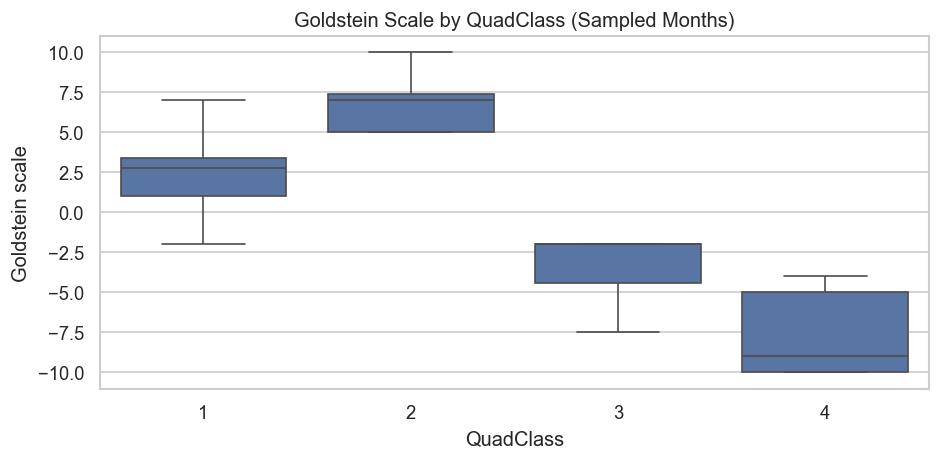

In [16]:
# Goldstein by QuadClass
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df_sample, x="quad_class", y="goldstein_scale", ax=ax, showfliers=False)
ax.set_title("Goldstein Scale by QuadClass (Sampled Months)")
ax.set_xlabel("QuadClass")
ax.set_ylabel("Goldstein scale")
plt.tight_layout()

**Goldstein aligns with QuadClass polarity: class 2 is strongly positive, class 4 strongly negative, class 3 moderately negative, class 1 mildly positive.** This supports keeping QuadClass as a categorical edge feature alongside Goldstein rather than dropping it.

,count,mean,median
pair,,,
USA-USA,1083037,0.311316,1.0
GBR-GBR,115193,0.771731,1.9
USA-RUS,99856,-0.194419,0.0
USA-UKR,89337,1.804787,2.8
USA-ISR,85587,0.720882,1.9
USA-CHN,83306,0.883994,1.0
RUS-USA,74825,-0.045141,0.4
CHN-USA,73885,0.785105,1.0
GBR-USA,68262,1.078669,1.9


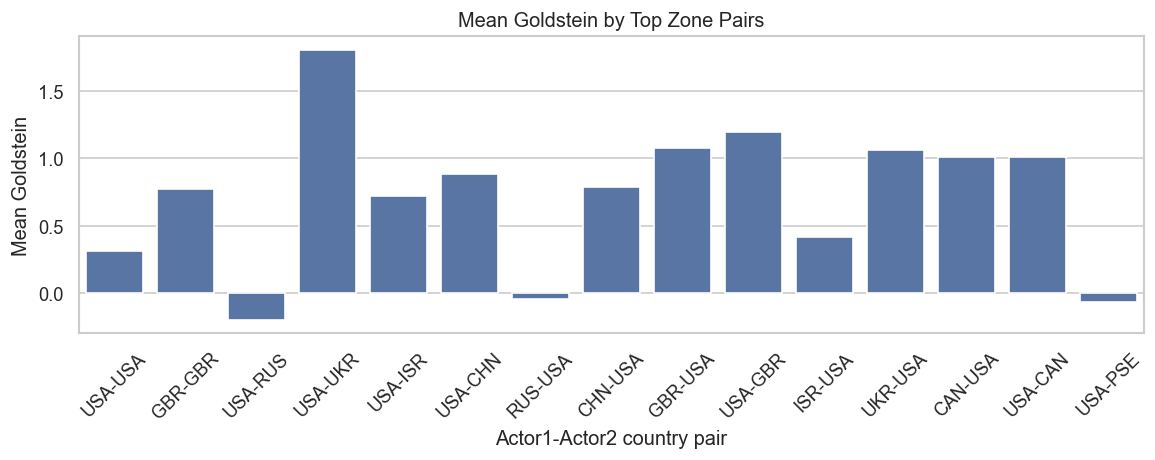

In [17]:
# Goldstein by top zone pairs
pair_series = df_sample[["actor1_country_code", "actor2_country_code"]].dropna()
pair_series["pair"] = pair_series["actor1_country_code"] + "-" + pair_series["actor2_country_code"]
top_pairs = pair_series["pair"].value_counts().head(15).index

goldstein_by_pair = (
    df_sample.assign(pair=pair_series["pair"])
    .dropna(subset=["pair", "goldstein_scale"])
    .query("pair in @top_pairs")
    .groupby("pair")["goldstein_scale"]
    .agg(["count", "mean", "median"])
    .sort_values("count", ascending=False)
 )

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=goldstein_by_pair.index, y=goldstein_by_pair["mean"], ax=ax)
ax.set_title("Mean Goldstein by Top Zone Pairs")
ax.set_xlabel("Actor1-Actor2 country pair")
ax.set_ylabel("Mean Goldstein")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

goldstein_by_pair.head(10)

**Top pairs are dominated by USA-centric interactions (USA-USA is 1.08M events), with Russia-related pairs slightly negative on average.** The zone-pair signal is asymmetric and likely informative for edge features, but a few pairs dominate volume.

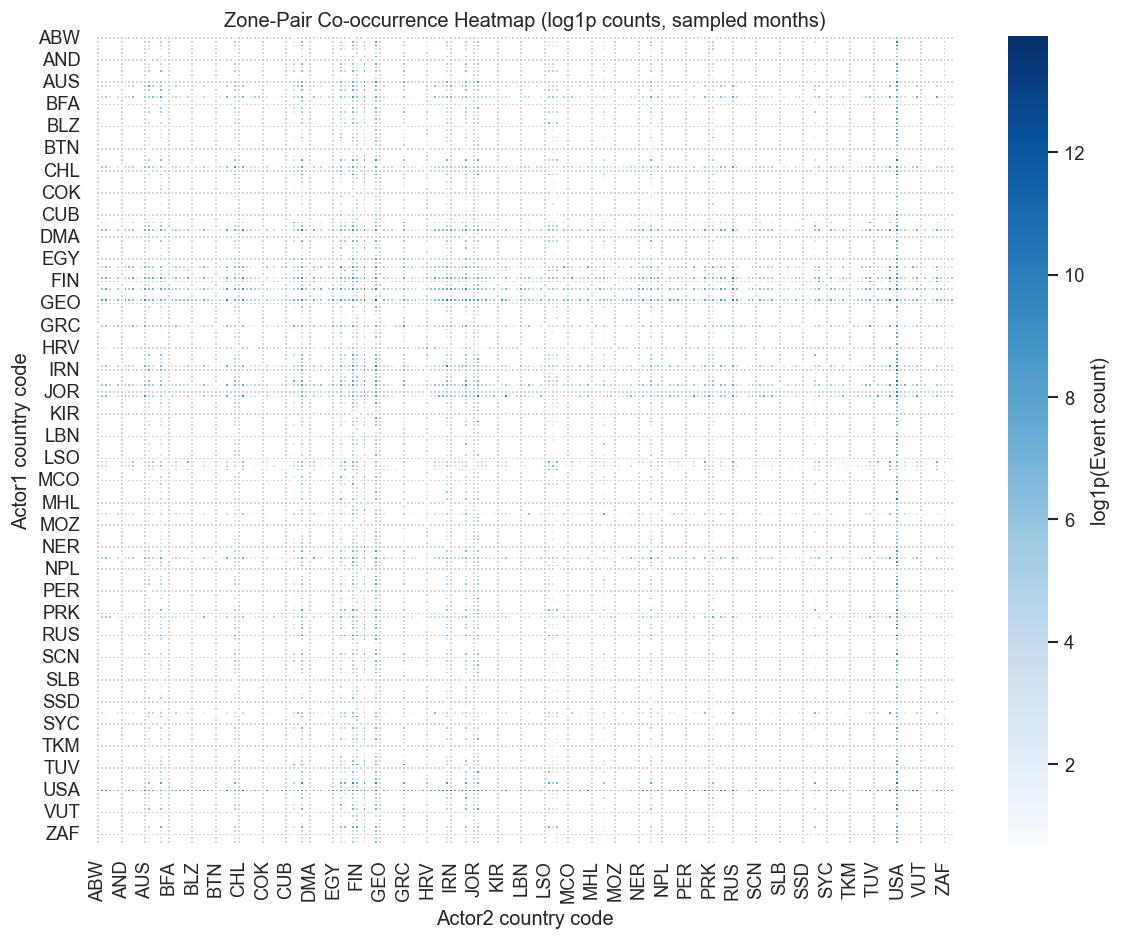

In [18]:
# Zone-pair density heatmap (Actor1CountryCode x Actor2CountryCode)
import numpy as np

pair_df = df_sample[["actor1_country_code", "actor2_country_code"]].dropna()
pair_matrix = pd.crosstab(pair_df["actor1_country_code"], pair_df["actor2_country_code"])

# Log scale + zero mask so sparse matrices are visible
pair_matrix_log = np.log1p(pair_matrix)
zero_mask = pair_matrix == 0

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pair_matrix_log,
    cmap="Blues",
    ax=ax,
    cbar_kws={"label": "log1p(Event count)"},
    linewidths=0.1,
    mask=zero_mask,
 )
ax.set_title("Zone-Pair Co-occurrence Heatmap (log1p counts, sampled months)")
ax.set_xlabel("Actor2 country code")
ax.set_ylabel("Actor1 country code")
plt.tight_layout()

**The co-occurrence matrix is extremely sparse with a few very dense cells (notably USA-related pairs).** Graph density is low overall, indicating a skewed degree distribution and potential need for normalization or sampling in the GAT.

In [19]:
# Density of country-pair matrix
nonzero_pairs = (pair_matrix > 0).sum().sum()
total_pairs = pair_matrix.shape[0] * pair_matrix.shape[1]
pair_density = nonzero_pairs / total_pairs
pair_density

np.float64(0.15456308250453493)

**Only ~15.5% of country-pair cells are non-zero.** The graph is sparse at the country-pair level, reinforcing the need for careful negative sampling or sparsity-aware modeling.

In [20]:
# Actor diversity: unique actor codes and country-vs-institution proxy
actor1_unique = df_sample["actor1_code"].nunique(dropna=True)
actor2_unique = df_sample["actor2_code"].nunique(dropna=True)

actor1_country_match = (df_sample["actor1_code"] == df_sample["actor1_country_code"]).mean()
actor2_country_match = (df_sample["actor2_code"] == df_sample["actor2_country_code"]).mean()

pd.DataFrame({
    "unique_actor_codes": [actor1_unique, actor2_unique],
    "country_code_match_rate": [actor1_country_match, actor2_country_match],
}, index=["actor1", "actor2"])

,unique_actor_codes,country_code_match_rate
actor1,7008,0.597017
actor2,7025,0.468168


**Actor codes are diverse (~7,000 unique per side), and only ~60% (Actor1) / ~47% (Actor2) match country codes.** This implies a large share of events involve non-country actors (institutions, groups), which supports a heterogeneous node set in the GAT.

In [21]:
# Temporal graph structure (monthly): node count, edge count, avg degree
df_sample["month_start"] = df_sample["event_date"].dt.to_period("M").dt.to_timestamp()
monthly_graph = (
    df_sample.groupby("month_start")
    .apply(
        lambda g: pd.Series({
            "edge_count": len(g),
            "node_count": pd.concat([g["actor1_code"], g["actor2_code"]]).nunique(dropna=True),
        }),
        include_groups=False,
    )
    .reset_index()
)
monthly_graph["avg_degree"] = 2 * monthly_graph["edge_count"] / monthly_graph["node_count"]
monthly_graph.head()

,month_start,edge_count,node_count,avg_degree
0,2012-01-01,205,46,8.913043
1,2012-02-01,7,6,2.333333
2,2012-03-01,238,51,9.333333
3,2012-04-01,19,12,3.166667
4,2012-05-01,255,58,8.793103


In [22]:
# Sanity check: event_date range vs file dates
event_date_min = df_sample["event_date"].min()
event_date_max = df_sample["event_date"].max()
file_date_min = pd.to_datetime(files_in_range["date"]).min()
file_date_max = pd.to_datetime(files_in_range["date"]).max()
event_date_min, event_date_max, file_date_min, file_date_max

(Timestamp('2012-01-04 00:00:00'),
 Timestamp('2023-12-31 00:00:00'),
 Timestamp('2022-01-01 00:00:00'),
 Timestamp('2023-12-31 00:00:00'))

In [23]:
# How many rows have event_date outside the file date range?
out_of_range = (df_sample["event_date"] < file_date_min) | (df_sample["event_date"] > file_date_max)
out_of_range_rate = out_of_range.mean()
out_of_range_rate

np.float64(0.004459078590785908)

**About 0.45% of rows have `event_date` outside the file date range (including 2012).** We'll filter these out when computing temporal graph structure to avoid skewing monthly stats.

In [24]:
# Temporal graph structure (filtered by valid event_date)
df_valid = df_sample.loc[~out_of_range].copy()
df_valid["month_start"] = df_valid["event_date"].dt.to_period("M").dt.to_timestamp()

monthly_stats = []
for month, g in df_valid.groupby("month_start"):
    node_count = pd.concat([g["actor1_code"], g["actor2_code"]]).nunique(dropna=True)
    edge_count = len(g)
    avg_degree = 2 * edge_count / node_count if node_count else 0
    monthly_stats.append({
        "month_start": month,
        "node_count": node_count,
        "edge_count": edge_count,
        "avg_degree": avg_degree,
    })

monthly_graph = pd.DataFrame(monthly_stats).sort_values("month_start")
monthly_graph.head()

,month_start,node_count,edge_count,avg_degree
0,2022-01-01,3331,1205364,723.725008
1,2022-02-01,638,23044,72.238245
2,2022-03-01,3388,1454217,858.451594
3,2022-04-01,730,34788,95.309589
4,2022-05-01,3412,1354698,794.078546


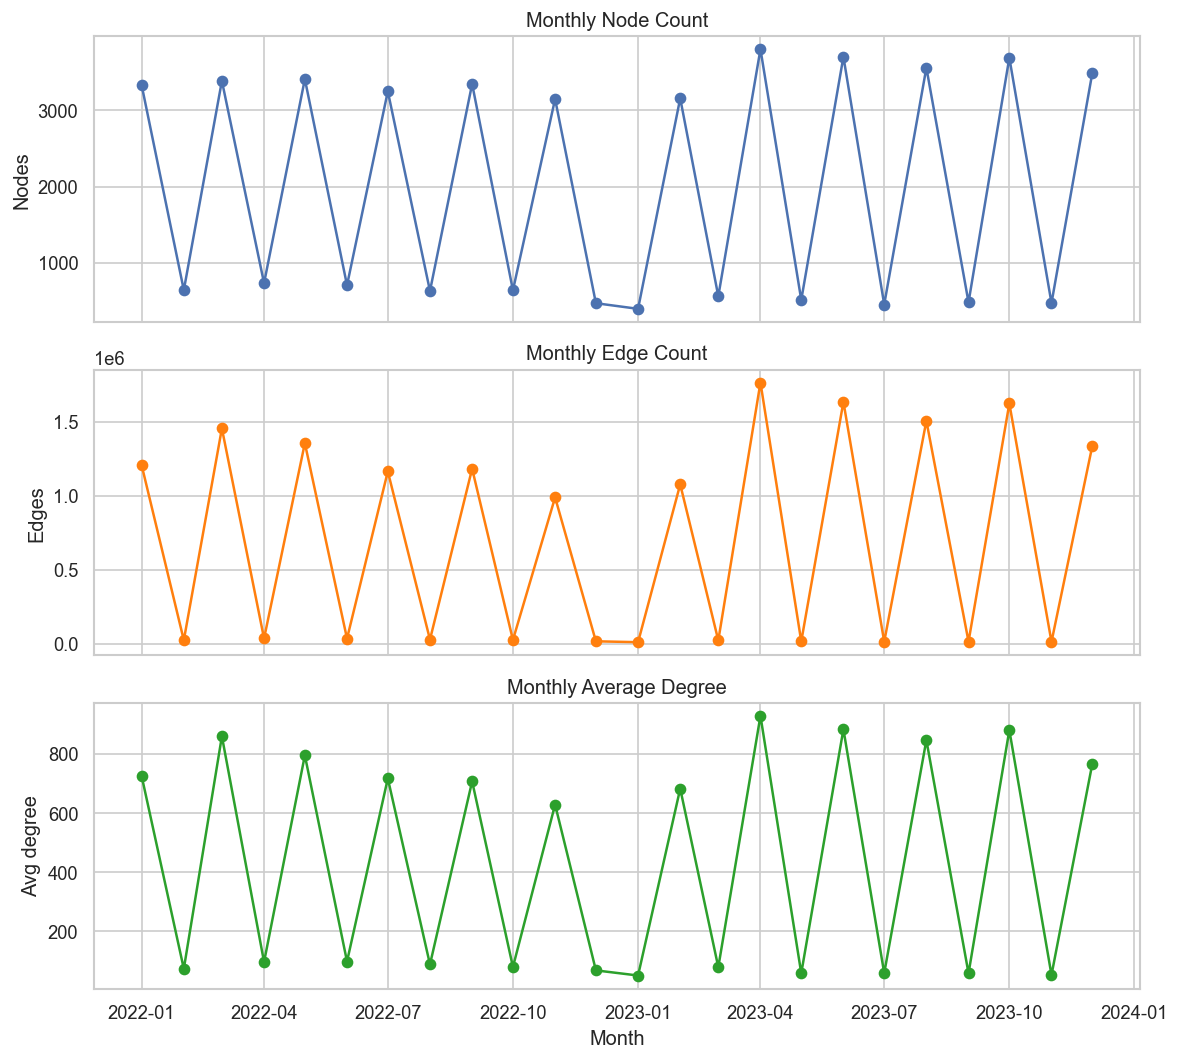

In [25]:
# Plot temporal graph structure
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(monthly_graph["month_start"], monthly_graph["node_count"], marker="o")
axes[0].set_title("Monthly Node Count")
axes[0].set_ylabel("Nodes")

axes[1].plot(monthly_graph["month_start"], monthly_graph["edge_count"], marker="o", color="tab:orange")
axes[1].set_title("Monthly Edge Count")
axes[1].set_ylabel("Edges")

axes[2].plot(monthly_graph["month_start"], monthly_graph["avg_degree"], marker="o", color="tab:green")
axes[2].set_title("Monthly Average Degree")
axes[2].set_ylabel("Avg degree")
axes[2].set_xlabel("Month")

plt.tight_layout()

**Monthly node/edge counts and average degree swing sharply across sampled months, with higher-density months recurring throughout 2022–2023.** Because this uses a 12-month sample, we should validate the pattern on full data before modeling temporal dynamics.

np.float64(0.3397510690693525)

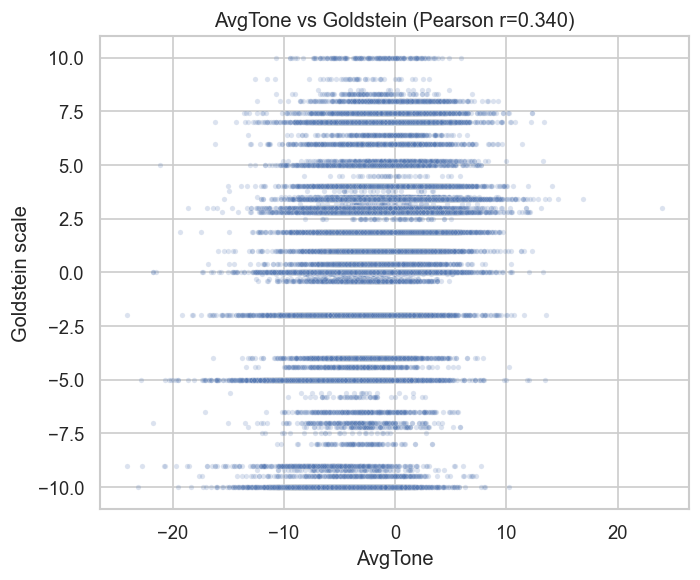

In [26]:
# AvgTone vs Goldstein correlation
corr = df_sample[["avg_tone", "goldstein_scale"]].corr(method="pearson").iloc[0, 1]
scatter_sample = df_sample[["avg_tone", "goldstein_scale"]].sample(50000, random_state=7)
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=scatter_sample, x="avg_tone", y="goldstein_scale", alpha=0.2, s=10, ax=ax)
ax.set_title(f"AvgTone vs Goldstein (Pearson r={corr:.3f})")
ax.set_xlabel("AvgTone")
ax.set_ylabel("Goldstein scale")
plt.tight_layout()
corr

**AvgTone and Goldstein are only moderately correlated (Pearson r=0.34).** They capture overlapping but distinct signal, so keeping both as edge features is reasonable.

(np.float64(0.42130996687744654), np.float64(0.2205015356820235))

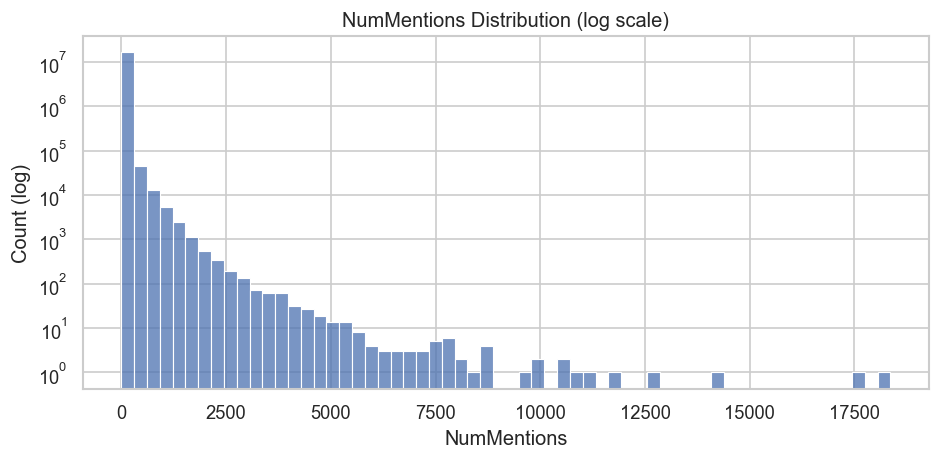

In [27]:
# NumMentions distribution and threshold share
mentions = df_sample["num_mentions"]
share_ge_5 = (mentions >= 5).mean()
share_ge_10 = (mentions >= 10).mean()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(mentions, bins=60, ax=ax)
ax.set_yscale("log")
ax.set_title("NumMentions Distribution (log scale)")
ax.set_xlabel("NumMentions")
ax.set_ylabel("Count (log)")
plt.tight_layout()
share_ge_5, share_ge_10

**NumMentions is extremely heavy-tailed; 42.1% of events have ≥5 mentions and 22.1% have ≥10.** Edge weighting based on mentions will need log/robust scaling to avoid a few events dominating.

event_root_code
04    4520687
01    2301715
05    1396445
03    1179551
02    1147469
11     987341
19     962549
17     871393
07     618017
08     575310
12     396880
06     383290
09     331508
18     228646
13     219326
Name: count, dtype: int64

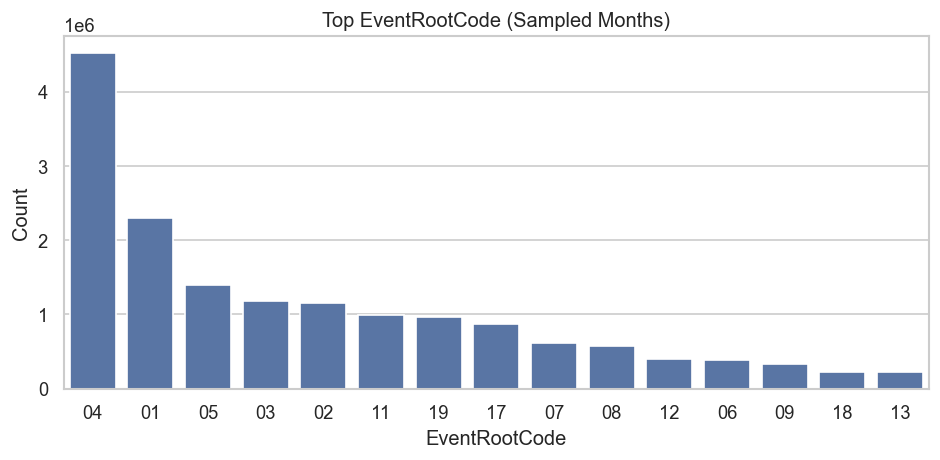

In [28]:
# Top EventRootCode values
root_counts = df_sample["event_root_code"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=root_counts.index.astype(str), y=root_counts.values, ax=ax)
ax.set_title("Top EventRootCode (Sampled Months)")
ax.set_xlabel("EventRootCode")
ax.set_ylabel("Count")
plt.tight_layout()
root_counts

**EventRootCode 04 dominates (4.52M), followed by 01 and 05.** The distribution is highly concentrated, which suggests a small set of event types drives most activity in the zone-filtered stream.

## Preprocessing Decisions

- **Drop QuadClass 1?** No. It represents ~63.5% of events, and Goldstein/QuadClass polarity is consistent; dropping would remove most of the signal without evidence of low quality.
- **Edge feature candidates:** `goldstein_scale`, `quad_class`, `avg_tone`, `num_mentions` (log-scaled), plus `num_sources`/`num_articles` as optional volume proxies.
- **High-null columns to treat carefully:** `actor1_type1_code`, `actor2_type1_code`, and `actor2_country_code` have large null rates and should be imputed or excluded.
- **Self-loops:** `USA→USA` is the highest-frequency pair (1.08M+ events in sample). The GAT formulation must explicitly decide whether to include or exclude self-loops — they are real GDELT events (domestic political interactions) but may dominate attention weights and dilute cross-zone signal. Recommend excluding self-loops (Actor1CountryCode == Actor2CountryCode) during graph construction and evaluating the effect.
- **Data quality issues to fix:** filter zero-row days (2022-11-10, 2023-03-23), drop out-of-range `event_date` rows (~0.45%), and handle sparse country-pair matrix in modeling/sampling.

## Summary of Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | 0 missing days across 2022-01-01 to 2026-04-29; two zero-volume days exist. | Filter sentinel days to avoid artificial spikes in temporal models. |
| 2 | QuadClass 1 accounts for 63.5% of events. | Dropping class 1 would remove most data; keep unless quality issues are proven. |
| 3 | Goldstein aligns with QuadClass polarity; avg_tone and Goldstein correlate at r=0.34. | Keep both as complementary edge features. |
| 4 | Country-pair graph is sparse (~15.5% non-zero), with USA-centric pairs dominating. | Expect skewed degree distribution; consider sampling/normalization for GAT. |
| 5 | NumMentions is heavy-tailed (42.1% ≥5, 22.1% ≥10). | Use log/robust scaling for mention-based edge weighting. |

## Section A — FX Label Alignment

Purpose: load OHLCV, create daily FX labels, and measure overlap with GDELT coverage.

In [29]:
# Step 1 — discover OHLCV files (daily timeframe)
from scipy.stats import spearmanr
import numpy as np

ohlcv_dir = ROOT_DIR / "data/processed/ohlcv"
ohlcv_files = sorted(ohlcv_dir.glob("ohlcv_*.parquet"))
print("Found OHLCV files:")
for path in ohlcv_files:
    print("-", path)

d1_files = [p for p in ohlcv_files if ("D1" in p.name) or ("1440" in p.name)]
if d1_files:
    files_to_load = d1_files
else:
    files_to_load = ohlcv_files

ohlcv_frames = []
for path in files_to_load:
    df_ohlcv = pd.read_parquet(path)
    ohlcv_frames.append(df_ohlcv)

ohlcv = pd.concat(ohlcv_frames, ignore_index=True) if ohlcv_frames else pd.DataFrame()
if not d1_files and not ohlcv.empty and "timeframe" in ohlcv.columns:
    ohlcv = ohlcv[ohlcv["timeframe"].isin(["D1", "1440", "1D", "1d"])]

if not ohlcv.empty:
    ohlcv["timestamp_utc"] = pd.to_datetime(ohlcv["timestamp_utc"], utc=True, errors="coerce")
    ohlcv = ohlcv.dropna(subset=["timestamp_utc", "pair"]).copy()
    ohlcv["date"] = ohlcv["timestamp_utc"].dt.date
    pair_ranges = (
        ohlcv.groupby("pair")["date"]
        .agg(["min", "max", "count"])
        .rename(columns={"min": "start_date", "max": "end_date", "count": "rows"})
        .reset_index()
    )
    print("\nDaily OHLCV pair ranges:")
    print(pair_ranges)
else:
    print("No OHLCV data loaded. Please check the ohlcv directory or file formats.")

Found OHLCV files:
- D:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\ohlcv_ADAUSDm_D1_2021-08-16_2024-08-08.parquet
- D:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\ohlcv_ADAUSDm_H1_2021-08-16_2024-08-08.parquet
- D:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\ohlcv_ADAUSDm_H4_2021-08-16_2024-08-08.parquet
- D:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\ohlcv_AUDJPYm_D1_2021-01-03_2025-12-30.parquet
- D:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\ohlcv_AUDJPYm_H1_2021-01-03_2025-12-30.parquet
- D:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\ohlcv_AUDJPYm_H4_2021-01-03_2025-12-30.parquet
- D:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\ohlcv_AUDUSDm_D1_2021-01-03_2025-12-30.parquet
- D:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\ohlcv_AUDUSDm_H1_2021-01-03_2025-12-30.parquet
- D:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\ohlcv_AUDUSDm_H4_2021-01-03_2025-12-30.parquet
- D:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\ohlcv_BTCUSDm_D1_2021-01-01_2025-12-30.parquet
- D:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\ohlcv

In [30]:
# Step 2 — compute labels per pair per trading day
if ohlcv.empty:
    fx_labels = pd.DataFrame(columns=["date", "pair", "next_day_return", "realized_vol_5d", "realized_vol_10d"])
else:
    ohlcv = ohlcv.sort_values(["pair", "timestamp_utc"])
    ohlcv["log_return"] = (
        np.log(ohlcv["close"]) - np.log(ohlcv["close"].shift(1))
    )
    ohlcv["next_close"] = ohlcv.groupby("pair")["close"].shift(-1)
    ohlcv["next_day_return"] = (ohlcv["next_close"] - ohlcv["close"]) / ohlcv["close"]
    ohlcv["realized_vol_5d"] = (
        ohlcv.groupby("pair")["log_return"]
        .rolling(window=5)
        .std()
        .reset_index(level=0, drop=True)
        * np.sqrt(252)
    )
    ohlcv["realized_vol_10d"] = (
        ohlcv.groupby("pair")["log_return"]
        .rolling(window=10)
        .std()
        .reset_index(level=0, drop=True)
        * np.sqrt(252)
    )
    fx_labels = ohlcv[["date", "pair", "next_day_return", "realized_vol_5d", "realized_vol_10d"]].copy()

print("fx_labels shape:", fx_labels.shape)
fx_labels.head()

fx_labels shape: (109041, 5)


,date,pair,next_day_return,realized_vol_5d,realized_vol_10d
0,2021-08-16,ADAUSDm,-0.041789,NaN,NaN
1,2021-08-17,ADAUSDm,0.045368,NaN,NaN
2,2021-08-18,ADAUSDm,0.129669,NaN,NaN
3,2021-08-19,ADAUSDm,0.059623,NaN,NaN
4,2021-08-20,ADAUSDm,0.155651,NaN,NaN


In [31]:
# Step 3 — align with GDELT dates
gdelt_dates = pd.to_datetime(files_df["date"]).dt.date
gdelt_date_min = min(gdelt_dates) if len(gdelt_dates) else None
gdelt_date_max = max(gdelt_dates) if len(gdelt_dates) else None
gdelt_days = len(set(gdelt_dates))

coverage_rows = []
if not fx_labels.empty:
    for pair, g in fx_labels.groupby("pair"):
        fx_days = set(g["date"].dropna())
        overlap_days = fx_days.intersection(set(gdelt_dates))
        overlap_pct = (len(overlap_days) / len(fx_days) * 100) if fx_days else 0
        coverage_rows.append({
            "pair": pair,
            "fx_days": len(fx_days),
            "gdelt_days": gdelt_days,
            "overlap_days": len(overlap_days),
            "overlap_pct": round(overlap_pct, 2),
        })

coverage_table = pd.DataFrame(coverage_rows).sort_values("pair")
print("GDELT date range:", gdelt_date_min, "to", gdelt_date_max)
print(coverage_table)
if not coverage_table.empty:
    low_overlap = coverage_table[coverage_table["overlap_pct"] < 80]
    if not low_overlap.empty:
        print("WARNING: <80% overlap:")
        print(low_overlap)

GDELT date range: 2022-01-01 to 2026-04-29
        pair  fx_days  gdelt_days  overlap_days  overlap_pct
0    ADAUSDm     1076        1580           951        88.38
1    AUDJPYm     1560        1580          1248        80.00
2    AUDUSDm     1560        1580          1248        80.00
3    BTCUSDm     1824        1580          1459        79.99
4      DE30m     1519        1580          1215        79.99
5   DOGEUSDm     1100        1580           951        86.45
6    DOTUSDm     1100        1580           951        86.45
7    ETHUSDm     1824        1580          1459        79.99
8    EURCADm     1560        1580          1248        80.00
9    EURCHFm     1560        1580          1248        80.00
10    EURGBP     7207        1580          1251        17.36
11   EURGBPm     3690        1580          1248        33.82
12    EURJPY     7206        1580          1251        17.36
13   EURJPYm     3690        1580          1248        33.82
14    EURUSD     7282        1580         

In [32]:
# Step 4 — zone-pair mapping
ZONE_PAIR_MAP = {
    "EURUSD": {
        "base_zones": [
            "EUR","AUT","BEL","CYP","DEU","ESP","EST","FIN","FRA",
            "GRC","HRV","IRL","ITA","LTU","LUX","LVA","MLT",
            "NLD","PRT","SVK","SVN",
        ],
        "quote_zones": ["USA"],
    },
    "GBPUSD": {"base_zones": ["GBR"], "quote_zones": ["USA"]},
    "USDJPY": {"base_zones": ["USA"], "quote_zones": ["JPN"]},
    "USDCHF": {"base_zones": ["USA"], "quote_zones": ["CHE"]},
}
ZONE_PAIR_MAP

{'EURUSD': {'base_zones': ['EUR',
   'AUT',
   'BEL',
   'CYP',
   'DEU',
   'ESP',
   'EST',
   'FIN',
   'FRA',
   'GRC',
   'HRV',
   'IRL',
   'ITA',
   'LTU',
   'LUX',
   'LVA',
   'MLT',
   'NLD',
   'PRT',
   'SVK',
   'SVN'],
  'quote_zones': ['USA']},
 'GBPUSD': {'base_zones': ['GBR'], 'quote_zones': ['USA']},
 'USDJPY': {'base_zones': ['USA'], 'quote_zones': ['JPN']},
 'USDCHF': {'base_zones': ['USA'], 'quote_zones': ['CHE']}}

## Section B — Baseline IC (Aggregated GDELT Features)

Purpose: quantify baseline predictive signal from daily GDELT aggregates before building a GAT.

In [33]:
# Step 1 — aggregate GDELT daily features per FX pair
gdelt_source = files_in_range if "files_in_range" in globals() and not files_in_range.empty else files_df
zero_day_set = set(pd.to_datetime(["2022-11-10", "2023-03-23"]).date)
gdelt_rows = []

for _, row in gdelt_source.iterrows():
    file_date = row.get("date")
    if pd.isna(file_date):
        continue
    if file_date in zero_day_set:
        continue
    path = row.get("path")
    if path is None:
        continue
    if not Path(path).exists():
        continue
    df_day = pd.read_parquet(
        path,
        columns=[
            "Actor1CountryCode","Actor2CountryCode","GoldsteinScale",
            "QuadClass","AvgTone","NumMentions",
        ],
    )
    if df_day.empty:
        continue
    df_day = df_day.rename(columns={
        "Actor1CountryCode": "actor1_country_code",
        "Actor2CountryCode": "actor2_country_code",
        "GoldsteinScale": "goldstein_scale",
        "QuadClass": "quad_class",
        "AvgTone": "avg_tone",
        "NumMentions": "num_mentions",
    })
    df_day["goldstein_scale"] = pd.to_numeric(df_day["goldstein_scale"], errors="coerce")
    df_day["quad_class"] = pd.to_numeric(df_day["quad_class"], errors="coerce")
    df_day["avg_tone"] = pd.to_numeric(df_day["avg_tone"], errors="coerce")
    df_day = df_day.dropna(subset=["actor1_country_code", "actor2_country_code"])

    for pair, zones in ZONE_PAIR_MAP.items():
        base = zones["base_zones"]
        quote = zones["quote_zones"]
        mask = (
            (df_day["actor1_country_code"].isin(base) & df_day["actor2_country_code"].isin(quote))
            | (df_day["actor1_country_code"].isin(quote) & df_day["actor2_country_code"].isin(base))
        )
        mask = mask & (df_day["actor1_country_code"] != df_day["actor2_country_code"])
        subset = df_day[mask]
        event_count = len(subset)
        gdelt_rows.append({
            "date": file_date,
            "pair": pair,
            "mean_goldstein": subset["goldstein_scale"].mean() if event_count else np.nan,
            "sum_goldstein": subset["goldstein_scale"].sum() if event_count else 0.0,
            "conflict_ratio": (subset["quad_class"].isin([3, 4]).mean() if event_count else np.nan),
            "log_event_count": np.log1p(event_count),
            "mean_avg_tone": subset["avg_tone"].mean() if event_count else np.nan,
        })

gdelt_features = pd.DataFrame(gdelt_rows)
print("gdelt_features shape:", gdelt_features.shape)
gdelt_features.head()

gdelt_features shape: (2912, 7)


,date,pair,mean_goldstein,sum_goldstein,conflict_ratio,log_event_count,mean_avg_tone
0,2022-01-01,EURUSD,0.700282,247.9,0.217514,5.872118,-0.986117
1,2022-01-01,GBPUSD,-0.224742,-43.6,0.340206,5.273000,-2.840806
2,2022-01-01,USDJPY,1.582143,44.3,0.178571,3.367296,-2.630469
3,2022-01-01,USDCHF,0.826667,12.4,0.266667,2.772589,-3.781586
4,2022-01-02,EURUSD,1.164577,371.5,0.200627,5.768321,-1.455979


In [34]:
# Step 2 — merge with FX labels (lagged)
merged_by_lag = {}
lags = [1, 5, 10]
for lag in lags:
    shifted = gdelt_features.copy()
    shifted["date"] = pd.to_datetime(shifted["date"]) + pd.Timedelta(days=lag)
    shifted["date"] = shifted["date"].dt.date
    merged = shifted.merge(fx_labels, on=["date", "pair"], how="inner")
    merged_by_lag[lag] = merged
    print(f"Lag {lag}: merged rows = {len(merged)}")

Lag 1: merged rows = 1868
Lag 5: merged rows = 1868
Lag 10: merged rows = 1868


In [35]:
# Step 3 — Spearman IC per feature per lag
feature_cols = ["mean_goldstein", "sum_goldstein", "conflict_ratio", "log_event_count", "mean_avg_tone"]
label_cols = ["next_day_return", "realized_vol_5d", "realized_vol_10d"]

ic_rows = []
for lag, merged in merged_by_lag.items():
    for pair, g in merged.groupby("pair"):
        for feature in feature_cols:
            for label in label_cols:
                sub = g[[feature, label]].dropna()
                if len(sub) < 3:
                    ic = np.nan
                    p_val = np.nan
                else:
                    ic, p_val = spearmanr(sub[feature], sub[label], nan_policy="omit")
                ic_rows.append({
                    "lag": lag,
                    "pair": pair,
                    "feature": feature,
                    "label": label,
                    "ic": ic,
                    "p_value": p_val,
                })

ic_results = pd.DataFrame(ic_rows)
ic_results["abs_ic"] = ic_results["ic"].abs()
ic_results["meaningful"] = (ic_results["abs_ic"] > 0.05) & (ic_results["p_value"] < 0.05)
print(ic_results.sort_values("abs_ic", ascending=False).head(20))
print("Meaningful IC count:", ic_results["meaningful"].sum())

     lag    pair          feature             label        ic       p_value  \
56     5  EURUSD  log_event_count  realized_vol_10d -0.219600  3.060603e-08   
71     5  GBPUSD  log_event_count  realized_vol_10d -0.205715  2.271156e-07   
50     5  EURUSD    sum_goldstein  realized_vol_10d -0.202616  3.394424e-07   
28     1  GBPUSD    mean_avg_tone   realized_vol_5d  0.191670  1.469578e-06   
29     1  GBPUSD    mean_avg_tone  realized_vol_10d  0.188927  2.083602e-06   
74     5  GBPUSD    mean_avg_tone  realized_vol_10d  0.186766  2.733515e-06   
49     5  EURUSD    sum_goldstein   realized_vol_5d -0.181966  4.855142e-06   
104   10  EURUSD    mean_avg_tone  realized_vol_10d -0.170466  1.888962e-05   
55     5  EURUSD  log_event_count   realized_vol_5d -0.168363  2.399209e-05   
86     5  USDJPY  log_event_count  realized_vol_10d -0.159256  6.536439e-05   
26     1  GBPUSD  log_event_count  realized_vol_10d -0.156683  8.706601e-05   
119   10  GBPUSD    mean_avg_tone  realized_vol_10d 

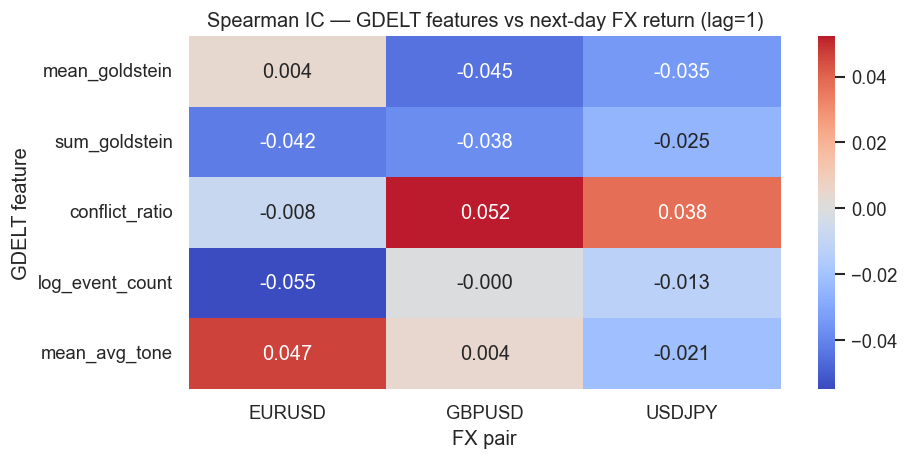

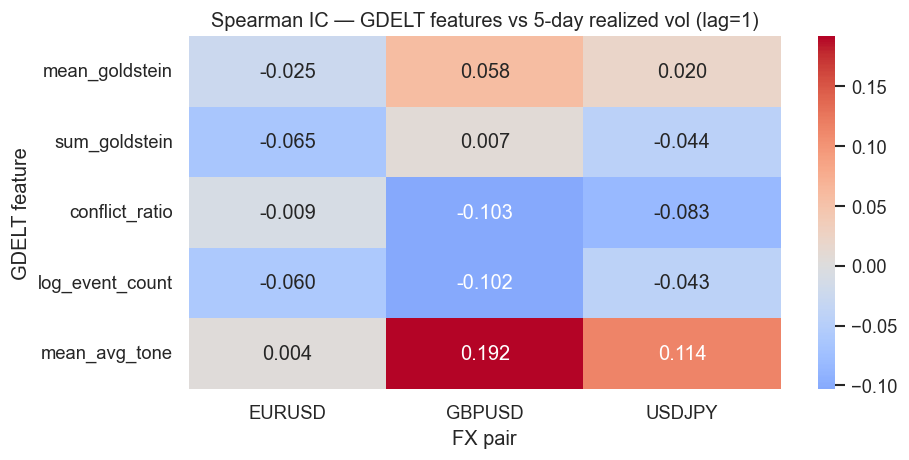

In [36]:
# Step 4 — IC heatmaps (lag=1)
lag1 = ic_results[ic_results["lag"] == 1]

def plot_ic_heatmap(label_name, title):
    pivot = (
        lag1[lag1["label"] == label_name]
        .pivot(index="feature", columns="pair", values="ic")
        .reindex(feature_cols)
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(
        pivot,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".3f",
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("FX pair")
    ax.set_ylabel("GDELT feature")
    plt.tight_layout()

plot_ic_heatmap(
    "next_day_return",
    "Spearman IC — GDELT features vs next-day FX return (lag=1)",
 )
plot_ic_heatmap(
    "realized_vol_5d",
    "Spearman IC — GDELT features vs 5-day realized vol (lag=1)",
 )

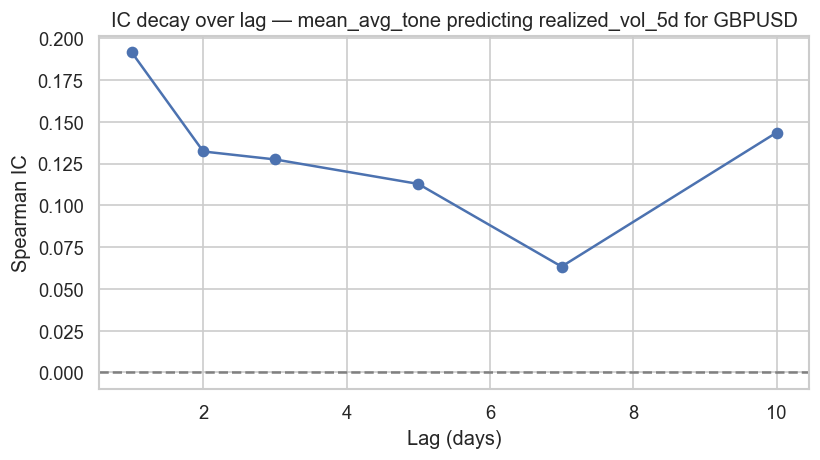

In [37]:
# Step 5 — IC over lags for best combination at lag=1
lags_full = [1, 2, 3, 5, 7, 10]
best_row = lag1.loc[lag1["abs_ic"].idxmax()] if not lag1.empty else None

if best_row is None or pd.isna(best_row["ic"]):
    print("No valid IC values for lag=1.")
else:
    best_feature = best_row["feature"]
    best_label = best_row["label"]
    best_pair = best_row["pair"]
    ic_by_lag = []
    for lag in lags_full:
        shifted = gdelt_features.copy()
        shifted["date"] = pd.to_datetime(shifted["date"]) + pd.Timedelta(days=lag)
        shifted["date"] = shifted["date"].dt.date
        merged = shifted.merge(fx_labels, on=["date", "pair"], how="inner")
        sub = merged[merged["pair"] == best_pair][[best_feature, best_label]].dropna()
        if len(sub) < 3:
            ic = np.nan
        else:
            ic, _ = spearmanr(sub[best_feature], sub[best_label], nan_policy="omit")
        ic_by_lag.append({"lag": lag, "ic": ic})

    ic_by_lag = pd.DataFrame(ic_by_lag)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(ic_by_lag["lag"], ic_by_lag["ic"], marker="o")
    ax.axhline(0, linestyle="--", color="gray")
    ax.set_title(
        f"IC decay over lag — {best_feature} predicting {best_label} for {best_pair}"
)
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Spearman IC")
    plt.tight_layout()

## Empirical Conclusion (Baseline IC)

- **Go / No-go (|IC| > 0.05, p < 0.05):** Mixed. Return ICs are small (|IC| ≤ 0.055 at lag=1), while volatility ICs show stronger structure (up to 0.192).
- **Most informative features:** `mean_avg_tone` stands out for volatility (GBPUSD 0.192, USDJPY 0.114). `conflict_ratio` and `log_event_count` show moderate negative IC for GBPUSD vol (~-0.10).
- **Most responsive FX pairs:** GBPUSD shows the strongest volatility response; USDJPY is secondary; EURUSD is weak across features.
- **Strongest lag:** Lag=1 is strongest for the top combo (mean_avg_tone → 5d vol on GBPUSD), with decay but still positive through lag=10.
- **Conclusion:** GAT is **justified for volatility-oriented targets** based on the baseline IC. For **next-day returns**, signal is weak, so a GAT for return prediction is **not yet justified** without feature engineering or alternative labels.